# Fase GNSS øvelse

## Indledende kode
Først skal vi importere de funktioner vi skal bruge til at beregne og visualisere vores observationer.

In [ ]:
from math import sqrt
from numpy import array, linspace
from matplotlib import pyplot as plt
import matplotlib
matplotlib.rcParams['axes.formatter.useoffset'] = False
matplotlib.rcParams['axes.formatter.limits'] = (-5, 8)
from scipy import stats
from pyproj import Transformer

## NRCAN
For at få en PPP løsning bruger vi NRCAN til at processere : 

1. Gå ind på NRCANs hjemmeside https://webapp.csrs-scrs.nrcan-rncan.gc.ca/geod/tools-outils/ppp.php?locale=en
2. Lav en profil
3. Log ind på din profil
4. Vælg 'Static'
5. Vælg 'ITRF'
6. Tryk på choose file og vælg din observationsfil (.22o)
7. Tryk submit to PPP

Nedenfor kan I se et screenshot af hjemmesiden med de rigtige indstillinger.

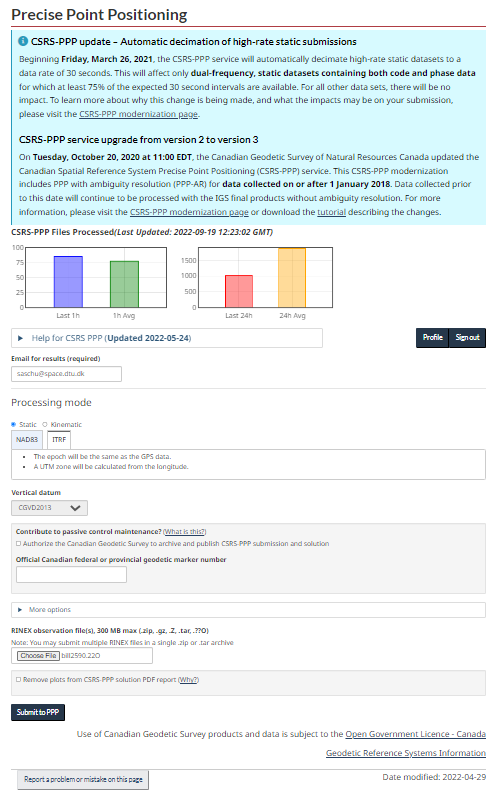


## Observationer
Vi kan nu samle positionerne og spredningerne fra de forsekllige metoder vi har brugt intil nu.

TruePos : Jeres sande værdi for jeres givne fikspunkt

kodePos : Jeres kode løsning ved brug af jeres håndholdte GPS modtager ovenpå punktet

NRCAN : PPP løsning fra statisk observation ved brug af NRCAN <br>
NRCAN giver jer et koordinat i UTM zone 22 samt i geodætiske koordinater. For at lave en syntetisk baselinje, skal disse omregnes til kartesiske koordinater.

FasePos : Bruger PPP løsning fra NRCAN for jeres fikspunkt og referencestationen SISI til at lave en baselinje.

Indsæt PPP løsningerne i kartesiske koordinater de rigtige steder i scriptet under for at beregne jeres Fase position.

In [ ]:
FixPoint_nrcanPos_UTM = array([123123.123, 1231231.123, 123])       # <-- indsæt dine værdier fra NRCAN i UTM zone 22 her
FixPoint_true_UTM = array([123123.123, 1231231.123, 123])           # <-- indsæt værdier for dit punkt fra fikspunktsbeskrivelsen her i UTM zone 22
PPP_sisi_station_UTM = array([123123.123, 1231231.123, 123.123])    # <-- indsæt dine værdier for SISI stationen fra NRCAN for UTM zone 22 her

# Lad være med at ændre denne
SISI_true = array([1484554.0904, -2018970, 5845650.7593])

Vi har dog det problem at vi skal bruge positionerne i kartesiske koordinater.. derfor bliver vi altså nødt til at transformere koordinaterne. <br>
Brug det i har lært fra grupperegning 2, til at løse vores lille problem. Prøv rigtig gerne selv om i kan finde den rigtige pipeline før i spørger om hjælp :)

In [ ]:
# indsæt kode her som transformerer Fase positionen og PPP løsningen fra UTM zone 22 til kartesiske koordinater med korrekt ellipsoide. 
# inden i spørger om hjælp, så forsøg jer med at lave jeres egen pipeline, med inspiration fra grupperegning 2.

pipeline = ""
transform_object = Transformer.from_pipeline(pipeline)

# nrcan position
FixPoint_nrcanPos = transform_object.transform(*FixPoint_nrcanPos_UTM)

# Sisimiut stationen position
PPP_sisi = transform_object.transform(*PPP_sisi_station_UTM)

# fikspunkt position
FixPoint_true = transform_object.transform(*FixPoint_true_UTM)

print(f'PPP position for jeres statiske måling [x,y,z]: {FixPoint_nrcanPos}')
print(f'PPP position for Sisimiut stationen [x,y,z]: {PPP_sisi}')
print(f'Den sande position for jeres fikspunkt [x,y,z]: {FixPoint_true}')

PPP position for jeres statiske måling [x,y,z]: (1484584.840356037, -2018376.5857351539, 5845782.755689322)
PPP position for Sisimiut stationen [x,y,z]: (1484554.0281756655, -2018970.7272351552, 5845650.794369881)
Den sande position for jeres fikspunkt [x,y,z]: (1484592.6763128769, -2018386.6219159132, 5845816.095363718)


Her udregner vi en syntetisk baselinje, for at finde vores fase position

In [ ]:
Baselinje = array(FixPoint_nrcanPos) - array(PPP_sisi)
FasePos = tuple(array(SISI_true) + Baselinje)

print(f'Position for fasepositionen [x,y,z]: {FasePos}')

pipeline_toUTM = "+ellps=GRS80 +proj=pipeline +step +proj=cart +inv +step +proj=utm +zone=22"
transform_object_toUTM = Transformer.from_pipeline(pipeline_toUTM)

FasePos_utm = transform_object_toUTM.transform(*FasePos)

print(f'Position for fasepositionen i UTM: {FasePos_utm}')

Position for fasepositionen [x,y,z]: (np.float64(1484584.902856037), np.float64(-2018375.858335154), np.float64(5845782.720989322))
Position for fasepositionen i UTM: (383568.7668041909, 7427023.653317274, 53.740046930499375)


Nu skriver vi alle vores observationer op.

Find jeres gennemsnitlige kode position frem og indskriv den i kodePos <br>
Vi vil gerne sammenligne i UTM zone 22, da det er nemmere at forstå positionen i forhold til et [x, y, z] koordinat, så indskriv nedenstående koordinater i UTM zone 22

In [ ]:
kodePos = array([123123.123, 1231231.123, 123.123])  # <-- indsæt dine værdier her

truePos = FixPoint_true_UTM
fasePos = FasePos_utm
nrcanPos = FixPoint_nrcanPos_UTM

## Visuel vurdering af observationer

De forskellige positionerings metoder kan nu plottes og samenlignes visuelt.

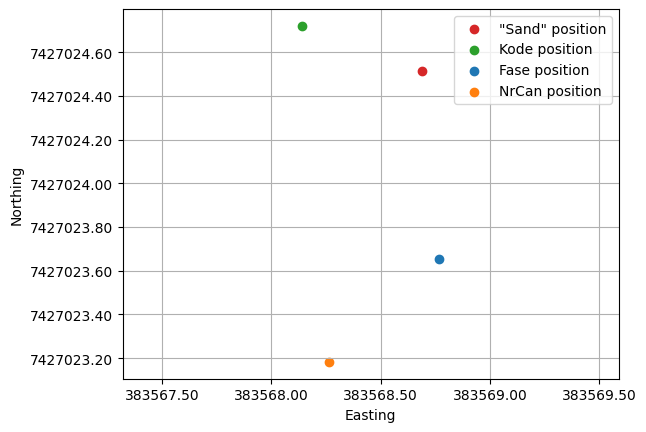

In [34]:
plt.figure()
plt.scatter(truePos[0], truePos[1], color='tab:red', label=f'"Sand" position')
plt.scatter(kodePos[0], kodePos[1], color='tab:green', label=f'Kode position')
plt.scatter(fasePos[0], fasePos[1], color='tab:blue', label=f'Fase position')
plt.scatter(nrcanPos[0], nrcanPos[1], color='tab:orange', label=f'NrCan position')

plt.xlabel('Easting')
plt.ylabel('Northing')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.gca().xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
plt.gca().yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
plt.show()

## Flere beregninger

Du bør nu lave yderligere beregninger for at dykke dybere ned i dine data. Lav beregninger og plots der beskriver dine data.

f.eks:

In [75]:
kodeDiff = kodePos - truePos
print(f'Forskel i kode positionering: [x,y,z] =  {kodeDiff}')

Forskel i kode positionering: [x,y,z] =  [ -0.548   0.205 -35.661]


# Kommentarer til resultaterne
Her skal I bruge 1/2 - 1 side på at beskrive jeres resultater. Brug de figurer og beregninger i har lavet!

f.eks:
  - Hvor tæt kom de forskellige metoder på den faktiske koordinat?
  - Hvor stor er spredningen ved brug af de forskellige metoder?
  - Stemmer resultaterne overens med det forventede i forhold til fejlteori og GNSS teori?
  - Skiller nogle metoder sig ud?